In [1]:
%%capture
!pip install facenet-pytorch

## Libraries

In [2]:
import sys
sys.path.append('/home/pj00/projects/Github/small_face_recognition_trcking/utils')

In [13]:
import numpy as np
import cv2
import time
import torch
import torchvision
from PIL import Image
from torchvision import transforms
from facenet_pytorch import MTCNN, InceptionResnetV1, fixed_image_standardization, training

from utils import extract_face, take_picture, detect_crop_image

%matplotlib inline
import matplotlib.pyplot as plt

## Functions

## Take image using camera OR Upload image

In [4]:
data_path = '/home/pj00/projects/Github/small_face_recognition_trcking/Data/finetuning_data'

In [5]:
frame = extract_face(save_path=data_path)

[ WARN:0@1.870] global /croot/opencv-suite_1691620365762/work/modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created
libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast


Photo taken!


In [6]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [7]:
mtcnn = MTCNN(
    image_size=112,
    margin=0,
    min_face_size=20,
    thresholds=[0.6, 0.7, 0.7],
    factor=0.709,
    post_process=False,
    device=device
)


In [8]:
transform = transforms.Compose([
            transforms.Resize((112, 112)),
            transforms.ToTensor(),
        ])

In [9]:
images, save_path = detect_crop_image(frame=frame, model=mtcnn, transform=transform, device=device)

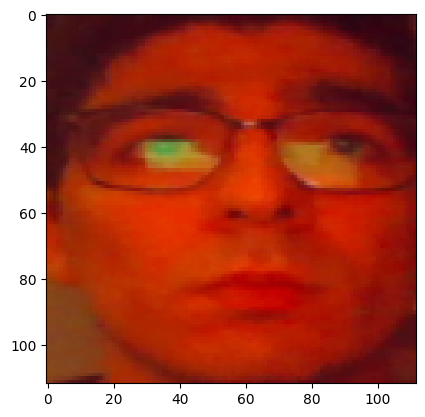

In [11]:
plt.imshow(images[0].detach().cpu().permute(1,2,0))

In [15]:
i = torchvision.transforms.functional.to_pil_image(images[0].detach().cpu(), mode=None)

In [19]:
i.save('asda.jpg')

In [14]:
num_classes = 1
if num_classes == 1:
    create_neg_class(path) # add 50 random images
    images= detect_crop_image(frame=frame, model=mtcnn, transform=transform, device=device)
    aug_img(save_path)
else:
    pass

NameError: name 'create_neg_class' is not defined